hwp5txt 엔진 연결 

In [15]:
import pandas as pd

# 한 단계 위로 나간 후 data 폴더로 접근
df = pd.read_csv('../data/data_list.csv')

print("=== Data Info ===")
df.info()

print("\n=== Data Head ===")
df.head()

=== Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   공고 번호      82 non-null     str    
 1   공고 차수      82 non-null     float64
 2   사업명        100 non-null    str    
 3   사업 금액      99 non-null     float64
 4   발주 기관      100 non-null    str    
 5   공개 일자      100 non-null    str    
 6   입찰 참여 시작일  74 non-null     str    
 7   입찰 참여 마감일  92 non-null     str    
 8   사업 요약      100 non-null    str    
 9   파일형식       100 non-null    str    
 10  파일명        100 non-null    str    
 11  텍스트        100 non-null    str    
dtypes: float64(2), str(10)
memory usage: 853.9 KB

=== Data Head ===


,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
0,20241001798,0.0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,130000000.0,한영대학,2024-10-04 13:51:23,NaN,2024-10-15 17:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 ...
1,20241002912,0.0,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,129300000.0,한국연구재단,2024-10-04 15:01:52,2024-10-14 10:00:00,2024-10-16 14:00:00,- 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선\n...,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,\r\n \r\n \r\n \r\n제 안 요 청 서\r\n[ 2024년 대학 ...
2,20240827859,0.0,EIP3.0 고압가스 안전관리 시스템 구축 용역,40000000.0,한국생산기술연구원,2024-08-28 11:31:02,2024-08-29 09:00:00,2024-09-09 10:00:00,- 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역\n- 추진배경: 안...,hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,\r\n \r\nEIP3.0 고압가스 안전관리\r\n시스템 구축 용역\...
3,20240430918,0.0,도시계획위원회 통합관리시스템 구축용역,150000000.0,인천광역시,2024-04-18 16:26:32,2024-05-02 10:00:00,2024-05-09 16:00:00,- 사업명: 도시계획위원회 통합관리시스템 구축 용역\n- 용역개요: 도시계획위원회와...,hwp,인천광역시_도시계획위원회 통합관리시스템 구축용역.hwp,\r\n \r\n \r\n도시계획위원회 통합관리시스템 구축\r\n제 안 요 청...
4,20240430896,0.0,봉화군 재난통합관리시스템 고도화 사업(협상)(긴급),900000000.0,경상북도 봉화군,2024-04-18 16:33:28,2024-04-26 09:00:00,2024-04-30 17:00:00,- 사업명: 봉화군 재난통합관리시스템 고도화 사업\n- 사업개요: 공동수급(공동이행...,hwp,경상북도 봉화군_봉화군 재난통합관리시스템 고도화 사업(협상)(긴급).hwp,\r\n \r\n \r\n제안요청서\r\n \r\n사 업 명\r\n봉화...


In [16]:
import os
import sys
import subprocess
import pandas as pd
import yaml
import re
import matplotlib.pyplot as plt
import seaborn as sns
from kiwipiepy import Kiwi
from collections import Counter

# 1. 가상환경 PATH 설정 (hwp5txt 엔진 로드용)
current_dir = os.getcwd()
venv_bin_path = os.path.abspath(os.path.join(current_dir, '..', '.venv', 'bin'))
if not os.path.exists(venv_bin_path):
    venv_bin_path = os.path.abspath(os.path.join(current_dir, '.venv', 'bin'))

if venv_bin_path not in os.environ['PATH']:
    os.environ['PATH'] = venv_bin_path + os.pathsep + os.environ['PATH']

# 2. 엔진 버전 확인
try:
    result = subprocess.run(['hwp5txt', '--version'], capture_output=True, text=True)
    print(f"🚀 엔진 준비 완료: {result.stdout.strip()}")
except Exception as e:
    print(f"❌ 엔진 에러: {e}")

# 3. 설정 로드
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

🚀 엔진 준비 완료: hwp5txt 0.1b15


In [17]:
# 프로젝트 루트 경로 추가 (모듈 호출용)
root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.preprocessing.pdf_hwp import RFPPipeline, RFPMeta

# 데이터 리스트 읽기
df = pd.read_csv(config['path']['data_list'])
pipeline = RFPPipeline(chunk_size=500, overlap=100) # 초기 로드용 설정

total_chunks = []
file_dir = config['path']['file_dir']

print(f"🚀 총 {len(df)}개 파일 분석 시작...")
for idx, row in df.iterrows():
    f_path = os.path.join(file_dir, str(row['파일명']).strip())
    if os.path.exists(f_path):
        try:
            chunks = pipeline.load_file(f_path)
            total_chunks.extend(chunks)
        except Exception as e:
            print(f"❌ {row['파일명']} 에러: {e}")

print(f"✅ 초기 청크 생성 완료: {len(total_chunks)}개")

2026-05-18 04:39:11,911 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/인천광역시_도시계획위원회 통합관리시스템 구축용역.hwp


🚀 총 100개 파일 분석 시작...


2026-05-18 04:39:18,431 [INFO] rfp_pipeline: [HWP] 추출 완료: 21,935자
2026-05-18 04:39:18,433 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/경상북도 봉화군_봉화군 재난통합관리시스템 고도화 사업(협상)(긴급).hwp
2026-05-18 04:39:24,116 [INFO] rfp_pipeline: [HWP] 추출 완료: 24,627자
2026-05-18 04:39:24,118 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/재단법인충북연구원_GIS통계 기반 재난안전데이터 분석ㆍ관리 시스템 구.hwp
2026-05-18 04:39:27,617 [INFO] rfp_pipeline: [HWP] 추출 완료: 15,382자
2026-05-18 04:39:27,619 [INFO] rfp_pipeline: [PDF] 파싱: ../data/files/고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf
2026-05-18 04:40:56,175 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/재단법인스포츠윤리센터_스포츠윤리센터 LMS(학습지원시스템) 기능개선.hwp


❌ 고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf 에러: Unable to get page count. Is poppler installed and in PATH?


2026-05-18 04:41:04,517 [INFO] rfp_pipeline: [HWP] 추출 완료: 21,219자
2026-05-18 04:41:04,522 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/국방과학연구소_대용량 자료전송시스템 고도화.hwp
2026-05-18 04:41:09,389 [INFO] rfp_pipeline: [HWP] 추출 완료: 11,482자
2026-05-18 04:41:09,392 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/(사）한국대학스포츠협의회_KUSF 체육특기자 경기기록 관리시스템 개발.hwp
2026-05-18 04:41:16,675 [INFO] rfp_pipeline: [HWP] 추출 완료: 14,407자
2026-05-18 04:41:16,677 [INFO] rfp_pipeline: [PDF] 파싱: ../data/files/서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf
2026-05-18 04:42:01,100 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp
2026-05-18 04:42:03,516 [INFO] rfp_pipeline: [HWP] 추출 완료: 24,085자
2026-05-18 04:42:03,519 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/국가과학기술지식정보서비스_통합정보시스템 고도화 용역.hwp
2026-05-18 04:42:10,464 [INFO] rfp_pipeline: [HWP] 추출 완료: 14,282자
2026-05-18 04:42:10,470 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/2025 구미 아시아육상경기선수권대회 조직위원회_2025 구미아시아육상경.hwp
2026-05-1

❌ 서울특별시_2024년 지도정보 플랫폼 및 전문활용 연계 시스템 고도화 용.pdf 에러: Unable to get page count. Is poppler installed and in PATH?


2026-05-18 04:44:26,114 [INFO] rfp_pipeline: [HWP] 추출 완료: 33,207자
2026-05-18 04:44:26,116 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/을지대학교_을지대학교 비교과시스템 개발.hwp
2026-05-18 04:44:30,154 [INFO] rfp_pipeline: [HWP] 추출 완료: 20,367자
2026-05-18 04:44:30,157 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/대전대학교_대전대학교 2024학년도 다층적 융합 학습경험 플랫폼(MILE) 전.hwp
2026-05-18 04:44:31,046 [WARNING] rfp_pipeline: [HWP] hwp5txt 실패 (code=0): ParseError: can't parse <class 'hwp5.dataio.BSTR'>
Caused by: UnicodeDecodeError('utf-16-le', b'\x19\xd9|\xb5\xdf8\xd4\x01\x14\x00 \x00', 0, 2, 'illegal UTF-16 surrogate')
Path: DocInfo
Treegroup: 1
R
2026-05-18 04:44:31,047 [WARNING] rfp_pipeline: [HWP] 바이너리 파싱 사용 (품질 낮음): ../data/files/대전대학교_대전대학교 2024학년도 다층적 융합 학습경험 플랫폼(MILE) 전.hwp
2026-05-18 04:44:31,147 [INFO] rfp_pipeline: [HWP] 추출 완료: 219,235자
2026-05-18 04:44:31,156 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/서영대학교 산학협력단_전문대학 혁신지원사업 서영대학교 차세대 교육.hwp
2026-05-18 04:44:36,877 [INFO] rfp_pipeline: [HWP] 추출 완료: 

❌ 기초과학연구원_2025년도 중이온가속기용 극저온시스템 운전 용역.pdf 에러: Unable to get page count. Is poppler installed and in PATH?


2026-05-18 04:45:04,618 [INFO] rfp_pipeline: [HWP] 추출 완료: 29,447자
2026-05-18 04:45:04,621 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/대검찰청_아태 사이버범죄 역량강화 허브(APC-HUB) 홈페이지 및 온라인 교.hwp
2026-05-18 04:45:08,402 [INFO] rfp_pipeline: [HWP] 추출 완료: 15,388자
2026-05-18 04:45:08,404 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/서민금융진흥원_서민금융진흥원 서민금융 채팅 상담시스템 구축.hwp
2026-05-18 04:45:13,538 [INFO] rfp_pipeline: [HWP] 추출 완료: 24,936자
2026-05-18 04:45:13,540 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/(사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp
2026-05-18 04:45:17,536 [INFO] rfp_pipeline: [HWP] 추출 완료: 16,489자
2026-05-18 04:45:17,538 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/수협중앙회_수협중앙회 수산물사이버직매장 시스템 재구축 ISMP 수립 입.hwp
2026-05-18 04:45:21,588 [INFO] rfp_pipeline: [HWP] 추출 완료: 35,940자
2026-05-18 04:45:21,590 [INFO] rfp_pipeline: [HWP] 로딩 시작: ../data/files/대한상공회의소_기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고.hwp
2026-05-18 04:45:26,012 [INFO] rfp_pipeline: [HWP] 추출 완료: 14,677자
2026-05-18 04:45:26,0

✅ 초기 청크 생성 완료: 1021개


In [3]:
from src.preprocessing.cleaner import RFPTextCleaner

cleaner = RFPTextCleaner(config)
final_chunks = cleaner.run_semantic_chunking(total_chunks)

print(f"🧹 정제 및 재분할 완료: {len(total_chunks)} -> {len(final_chunks)}개")

🧹 정제 및 재분할 완료: 1509 -> 2580개


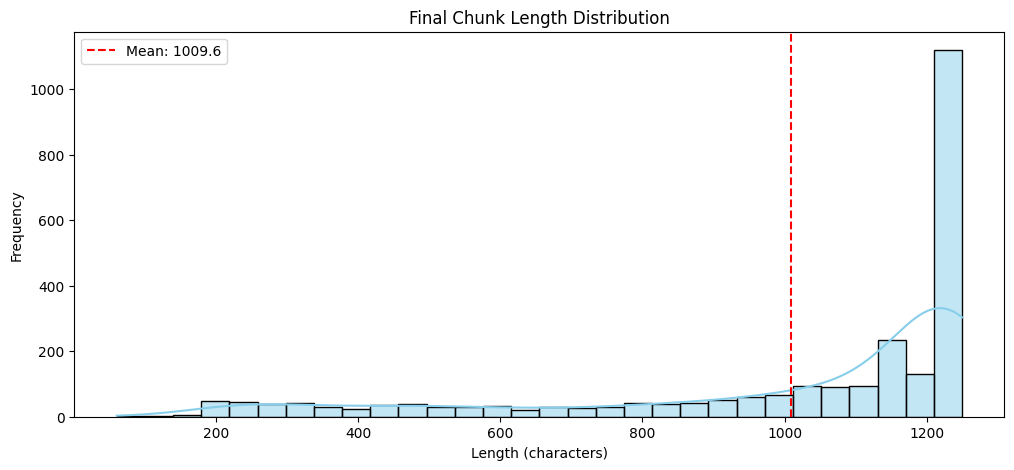

=== 청크 길이 통계 ===
count    2580.000000
mean     1009.576357
std       314.729688
min        60.000000
25%       896.000000
50%      1164.000000
75%      1235.000000
max      1250.000000
dtype: float64


In [4]:
plt.figure(figsize=(12, 5))
lengths = [len(c) for c in final_chunks]

sns.histplot(lengths, bins=30, kde=True, color='skyblue')
plt.title('Final Chunk Length Distribution')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')
plt.axvline(x=sum(lengths)/len(lengths), color='red', linestyle='--', label=f'Mean: {sum(lengths)/len(lengths):.1f}')
plt.legend()
plt.show()

# 통계치 출력
print("=== 청크 길이 통계 ===")
print(pd.Series(lengths).describe())

데이터 정제: 30자 미만의 짧은 청크 제외

🥝 키워드 추출 중...

🏆 Top 20 키워드 분포:
정보: 9243회
사업: 8765회
사항: 8140회
시스템: 7381회
계약: 7303회
평가: 6975회
관리: 6595회
경우: 5770회
입찰: 5376회
요구: 5211회
제안서: 4173회
제안: 3735회
내용: 3598회
기술: 3530회
제출: 3528회
수행: 3528회
기관: 3437회
보안: 3421회
기능: 3259회
기준: 2929회


/opt/jhub-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/jhub-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/jhub-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/jhub-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/jhub-venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54637 (\N{HANGUL SYLLABLE HANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

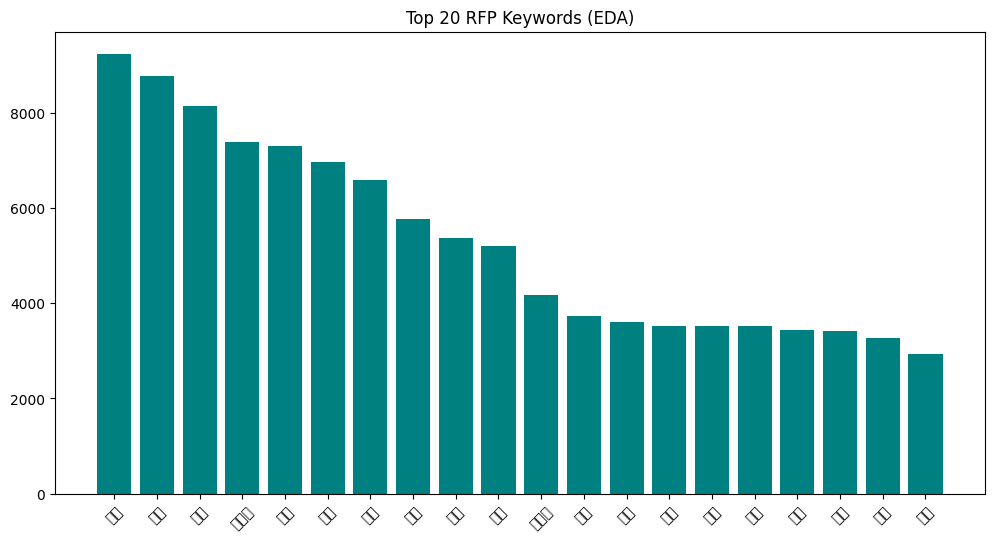

In [8]:
kiwi = Kiwi()
all_nouns = []

print("🥝 키워드 추출 중...")
for text in final_chunks:
    tokens = kiwi.tokenize(text)
    nouns = [t.form for t in tokens if t.tag in ['NNG', 'NNP'] and len(t.form) >= config['kiwi']['min_noun_len']]
    all_nouns.extend(nouns)

count = Counter(all_nouns)
common_keywords = count.most_common(20)

print("\n🏆 Top 20 키워드 분포:")
for word, freq in common_keywords:
    print(f"{word}: {freq}회")

# 막대 그래프
plt.figure(figsize=(12, 6))
words, counts = zip(*common_keywords)
plt.bar(words, counts, color='teal')
plt.title("Top 20 RFP Keywords (EDA)")
plt.xticks(rotation=45)
plt.show()

데이터 정제: 이상한 유니코드 및 특수문자 제거

In [9]:
print("--- [검증] 최종 청크 샘플 (의미 단위 절단 확인) ---")
for i in [10, 100, 500]:
    if i < len(final_chunks):
        print(f"\n[Chunk {i}]:\n{final_chunks[i][:300]}...")
        print("-" * 50)

--- [검증] 최종 청크 샘플 (의미 단위 절단 확인) ---

[Chunk 10]:
[인천광역시_도시계획위원회 통합관리시스템 구축용역] A4(210×297㎜)세로방향, 필요시 A3 첨부(반접하여 첨부) 가능 - 제본: 세로 좌철(풀칠 제본) - 표지: 백색, 무광택 사용 (서식에 따름) - 본문: 백상지, 단면인쇄, 각 쪽은 쉽게 참조할 수 있도록 페이지 하단에 일련번호를 예시(예시: - 1 -)와 같이 부여한다. - 제안서에 삽입하는 간지는 1쪽으로 인정하지 않는다. ○ 평가용 제안서 표지 등에는 제안회사를 인식할 수 있는 일체의 표기(사명, 로고, 마크 등)를 사용해서는 안 된다. ○ 모든 제안 서류는 한글표기...
--------------------------------------------------

[Chunk 100]:
[고려대학교_차세대 포털·학사 정보시스템 구축사업] ① 외국인학생 비자관리 정보화 지원 ② 외국인학생/어학연수생 관련 수작업 개선 ③ 외국인 학생/교원 맞춤형 영어서비스 지원 ④ 한국어과정 시스템 고도화 ❏ 국제교류협약관리 / 교류프로그램 관리 정보화 미흡 ❍ 국제교류 관련 프로그램 운영(신청-접수-등록) 수작업 발생 ❍ 해외대학과의 교육 협약관리 기능 미흡 -26- | ① 외국인학생 비자관리 정보화 지원 | | ② 외국인학생/어학연수생 관련 수작업 개선 | | ③ 외국인 학생/교원 맞춤형 영어서비스 지원 | | ④ 한국어과정 시스...
--------------------------------------------------

[Chunk 500]:
[고려대학교_차세대 포털·학사 정보시스템 구축사업] [ 서식 11 ] 하도급계약의 적정성 판단 세부기준 Ⅰ. 자격의 적정성 세부 판단 판단항목 세부 판단 기준 및 방법 항목 (재)하수급인 o 「국가계약법」또는 「지방계약법」에 따라 하수급인이 부정당업자로 감점 참가제한 의 자격 지정되어 입찰참가제한 중인 경우 (-25점) Ⅱ. 수행능력의 적정성 판단항목 세부 판단 항목 세부 판단 

### **RAG 전처리 전략 최적화 요약**

- **청킹 전략**: 제안서 특화 Recursive Character Splitting 적용

- **주요 성과**:

1. 단순 글자 수 분할 대비 청크 수 76% 증가(1,504 → 2,657)로 데이터 순도 향상
2. 목차 패턴(1., 가., ○)을 구분자로 활용하여 문맥 단절 최소화
3. 사업명 메타데이터 주입을 통해 검색 시 도메인 간섭 방지 및 검색 정확도 기반 마련